<a href="https://colab.research.google.com/github/Babior/ai-course-lab0/blob/main/lab0_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Exercise 4: NumPy Array Operations

In [3]:

import numpy as np

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0

matrix = np.ones((5, 5))
matrix[1:-1, 1:-1] = 0

print(matrix)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [2]:
# Task 2: Normalize a random array

np.random.seed(42)
random_data = np.random.randn(100, 3)

column_means = random_data.mean(axis=0)
column_stds = random_data.std(axis=0)

normalized_data = (random_data - column_means) / column_stds

print("Column means after normalization:")
print(normalized_data.mean(axis=0))

print("\nColumn standard deviations after normalization:")
print(normalized_data.std(axis=0))

Column means after normalization:
[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]

Column standard deviations after normalization:
[1. 1. 1.]


In [ ]:
# Task 3: Implement linear regression solution using normal equation

X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("True coefficients:")
print(true_theta)

print("\nEstimated coefficients:")
print(theta_hat)

print("\nDifference between true and estimated coefficients:")
print(theta_hat - true_theta)

Exercise 5: Pandas Data Analysis

In [5]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1
# Display basic information about the dataset
print("First 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
display(df.describe())

print("\nDataset shape:")
print(df.shape)

# Identify and count missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Fill missing exam_score with the mean score for the student's major
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing hours_studied with the median for the student's year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Task 1
# Calculate and display the average exam_score by major
average_score_by_major = df.groupby('major')['exam_score'].mean()

print("Average exam score by major:")
print(average_score_by_major)

# Find the major with the highest average exam_score
highest_avg_major = average_score_by_major.idxmax()
highest_avg_score = average_score_by_major.max()

print("\nMajor with highest average exam score:")
print(f"{highest_avg_major}: {highest_avg_score:.2f}")

# Calculate the correlation between hours_studied and exam_score
correlation = df['hours_studied'].corr(df['exam_score'])

print("\nCorrelation between hours studied and exam score:")
print(correlation)

# Create a new column 'performance'
def categorize_performance(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize_performance)

print("\nPerformance category counts:")
print(df['performance'].value_counts())

display(df.head())

# Task 3

# For each major and year combination, calculate:
# - Number of students
# - Average exam score
# - Average hours studied

major_year_summary = df.groupby(['major', 'year']).agg(
    number_of_students=('student_id', 'count'),
    average_exam_score=('exam_score', 'mean'),
    average_hours_studied=('hours_studied', 'mean')
)

print("Major and year summary:")
display(major_year_summary)

# Identify top 5 students based on exam_score
# nlargest handles top scores well
top_5_students = df.nlargest(5, 'exam_score')

print("\nTop 5 students based on exam score:")
display(top_5_students)

# Create a pivot table showing average exam_score by major and year
pivot_table = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("\nPivot table: Average exam score by major and year")
display(pivot_table)

First 5 rows:


,student_id,major,year,exam_score,assignments_completed,hours_studied
0,1000,Physics,3,68.199753,10,NaN
1,1001,Biology,4,77.322537,9,12.204873
2,1002,CS,3,77.930725,9,7.829556
3,1003,Physics,1,67.856486,2,14.042336
4,1004,Physics,4,93.657745,6,15.287370



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB

Statistical summary:


,student_id,year,exam_score,assignments_completed,hours_studied
count,200.000000,200.000000,190.000000,200.000000,195.000000
mean,1099.500000,2.615000,75.510638,4.700000,14.776761
std,57.879185,1.159091,9.582797,3.239207,5.251905
min,1000.000000,1.000000,42.587327,0.000000,1.295226
25%,1049.750000,2.000000,68.206910,2.000000,11.637963
50%,1099.500000,3.000000,75.728033,4.000000,14.575456
75%,1149.250000,4.000000,81.813642,8.000000,18.345691
max,1199.000000,4.000000,100.000000,10.000000,28.918887



Dataset shape:
(200, 6)

Missing values before cleaning:
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

Missing values after cleaning:
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            0
dtype: int64
Average exam score by major:
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64

Major with highest average exam score:
CS: 76.43

Correlation between hours studied and exam score:
-0.05598138347292439

Performance category counts:
performance
Average              77
Needs Improvement    59
Good                 52
Excellent            12
Name: count, dtype: int64


...

number_of_students  average_exam_score  average_hours_studied
major   year                                                               
Biology 1                     13           76.570059              12.677806
        2                     12           74.899613              13.426372
        3                     14           80.178476              14.486815
        4                     15           70.697689              14.253944
CS      1                     12           77.098194              13.039480
        2                      7           76.155936              13.995784
        3                      9           72.347626              15.039892
        4                     18           78.119997              16.275541
Math    1                     11           74.053167              19.001215
        2                      9           81.226714              12.345468
        3                     10           72.017537              15.175871
        4                     16           73.103066              17.419175
Physics 1                     13           77.828686              13.489911
        2                     12           73.277734              14.616778
        3                     17           73.134319              14.199901
        4                     12           78.130194              15.550491


Top 5 students based on exam score:


,student_id,major,year,exam_score,assignments_completed,hours_studied,performance
27,1027,Math,2,100.000000,4,2.716265,Excellent
57,1057,CS,2,100.000000,8,11.870035,Excellent
68,1068,Biology,3,98.146586,1,11.379991,Excellent
82,1082,CS,2,96.439441,0,7.378547,Excellent
132,1132,CS,4,96.330334,10,17.546891,Excellent



Pivot table: Average exam score by major and year


year,1,2,3,4
major,,,,
Biology,76.570059,74.899613,80.178476,70.697689
CS,77.098194,76.155936,72.347626,78.119997
Math,74.053167,81.226714,72.017537,73.103066
Physics,77.828686,73.277734,73.134319,78.130194


Exercise 6: Data Visualization

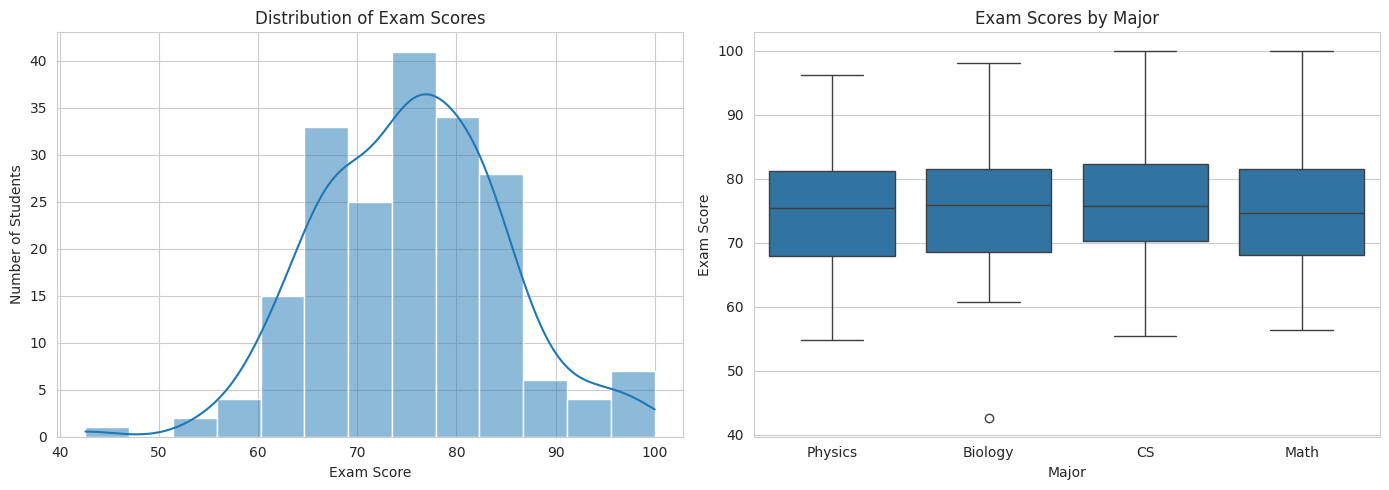

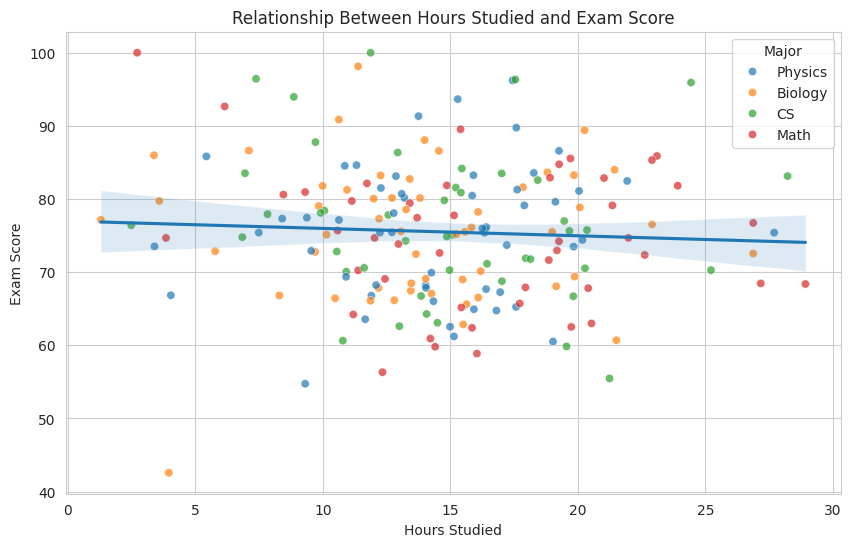

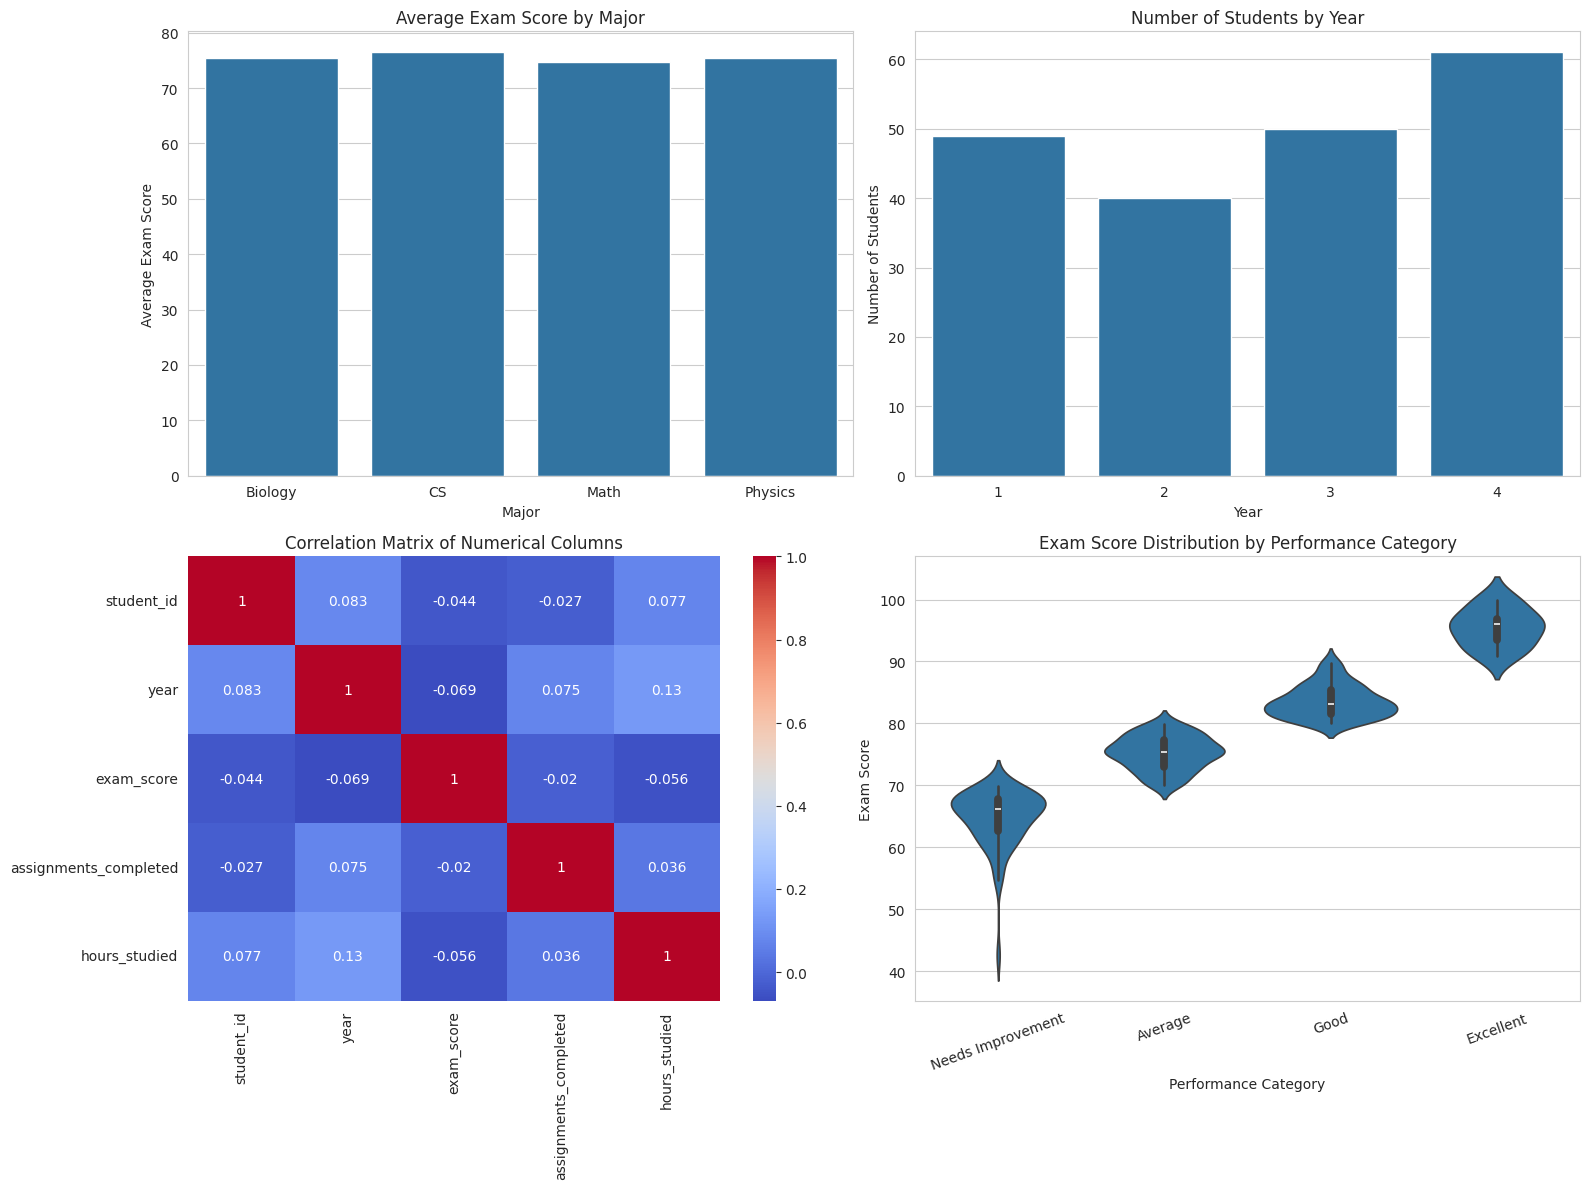

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_style("whitegrid")

# Task 1: Distribution Visualization
# Create a figure with 2 subplots side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of exam scores with KDE overlay
sns.histplot(
    data=df,
    x='exam_score',
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Number of Students')

# Right: Box plot of exam scores by major
sns.boxplot(
    data=df,
    x='major',
    y='exam_score',
    ax=axes[1]
)

axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

# Task 2: Relationship Visualization
# Scatter plot of hours_studied vs exam_score, colored by major

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major',
    alpha=0.7
)

# Add overall regression line
sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False
)

plt.title('Relationship Between Hours Studied and Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend(title='Major')
plt.show()

# Task 3: Advanced Dashboard
# Create a 2x2 subplot figure

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar chart: Average exam score by major
average_scores = df.groupby('major')['exam_score'].mean().reset_index()

sns.barplot(
    data=average_scores,
    x='major',
    y='exam_score',
    ax=axes[0, 0]
)

axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Exam Score')

# 2. Count plot: Number of students by year
sns.countplot(
    data=df,
    x='year',
    ax=axes[0, 1]
)

axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Number of Students')

# 3. Heat map: Correlation matrix of numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_columns.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    ax=axes[1, 0]
)

axes[1, 0].set_title('Correlation Matrix of Numerical Columns')

# 4. Violin plot: Exam score distribution by performance category
performance_order = ['Needs Improvement', 'Average', 'Good', 'Excellent']

sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    order=performance_order,
    ax=axes[1, 1]
)

axes[1, 1].set_title('Exam Score Distribution by Performance Category')
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [ ]:
Exercise 7: Integration Challenge

Customer data with churn risk and CLV:


,age,income,purchase_frequency,avg_purchase_value,churn_risk,CLV
0,56,92443.123940,7,94.527456,0.416667,937.397271
1,69,70649.305211,2,100.932279,0.833333,370.085023
2,46,19612.600681,3,79.699876,0.750000,418.424348
3,32,40315.318543,2,130.137787,0.833333,477.171887
4,60,75338.222984,8,102.904845,0.333333,1097.651683


Age group counts:
age_group
18-25     81
26-35     73
36-50    160
51-70    186
Name: count, dtype: int64


,age,income,purchase_frequency,avg_purchase_value,churn_risk,CLV,age_group
0,56,92443.123940,7,94.527456,0.416667,937.397271,51-70
1,69,70649.305211,2,100.932279,0.833333,370.085023,51-70
2,46,19612.600681,3,79.699876,0.750000,418.424348,36-50
3,32,40315.318543,2,130.137787,0.833333,477.171887,26-35
4,60,75338.222984,8,102.904845,0.333333,1097.651683,51-70


Customer summary by age group:


/tmp/ipykernel_20540/1033950398.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_summary = customers.groupby('age_group').agg(


,number_of_customers,average_income,average_CLV,total_CLV
age_group,,,,
18-25,81,50634.018330,718.371170,58188.064760
26-35,73,48747.148046,747.738562,54584.915035
36-50,160,48516.895668,732.796612,117247.457917
51-70,186,50713.163384,762.693498,141860.990683


CLV threshold for top 10% customers: 1222.94
Number of top customers: 50


,age,income,purchase_frequency,avg_purchase_value,churn_risk,CLV,age_group
426,42,68713.567863,8,154.285448,0.333333,1645.711441,36-50
213,41,45580.608009,7,164.920221,0.416667,1635.458860,36-50
410,44,49344.934596,6,177.097211,0.500000,1593.874900,36-50
194,44,57331.964922,6,176.640590,0.500000,1589.765308,36-50
244,28,29255.076913,7,159.784979,0.416667,1584.534373,26-35
423,43,34443.666248,6,173.245130,0.500000,1559.206172,36-50
386,63,24200.782005,9,136.030443,0.250000,1530.342482,51-70
187,47,48889.046022,8,143.183371,0.333333,1527.289296,36-50
361,38,27490.219054,7,153.105028,0.416667,1518.291532,36-50
180,62,44611.863311,7,151.961479,0.416667,1506.951331,51-70


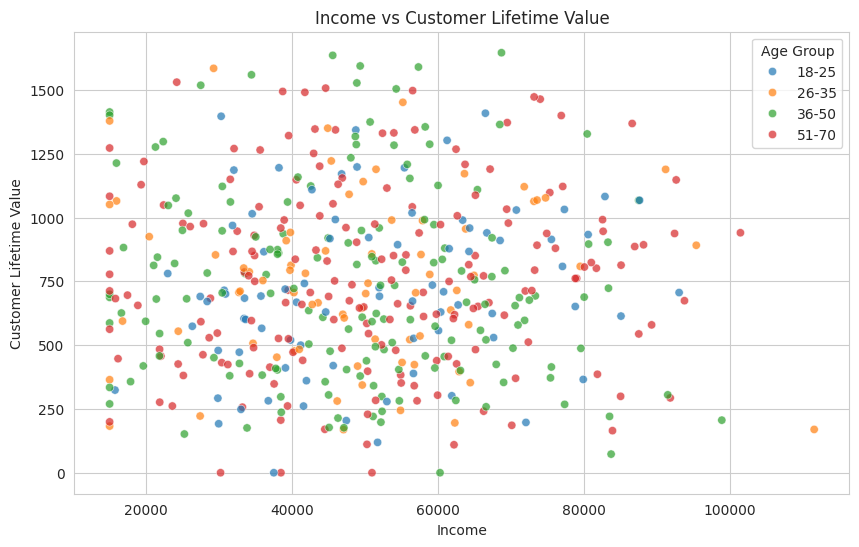

/tmp/ipykernel_20540/1033950398.py:107: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_clv_by_age = customers.groupby('age_group')['CLV'].mean().reset_index()


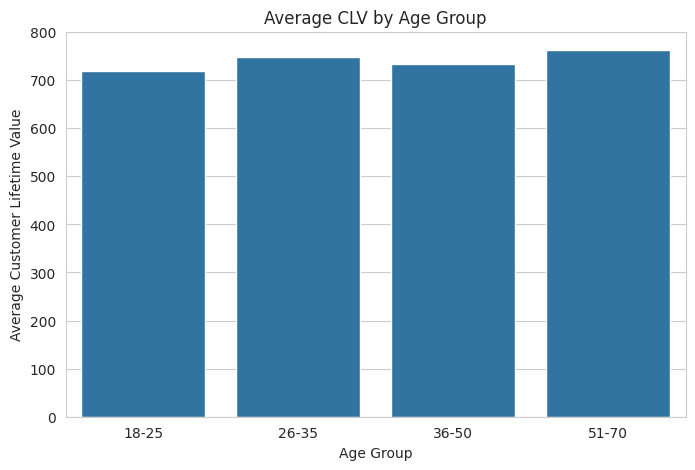

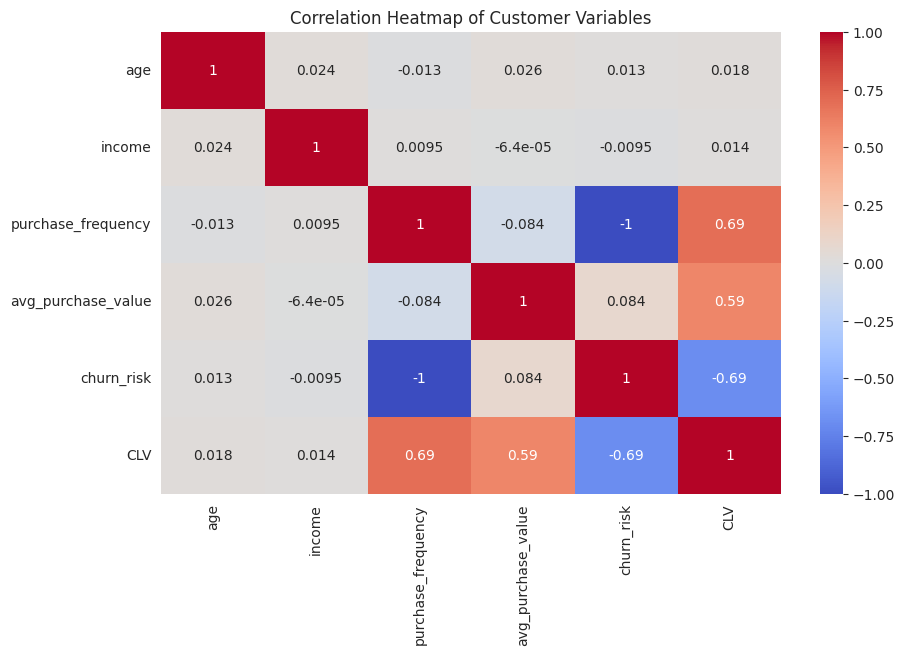

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# Calculate customer lifetime value (CLV)
# CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
# churn_risk = 1 - (purchase_frequency / max_frequency)

max_frequency = customers['purchase_frequency'].max()

customers['churn_risk'] = 1 - (
    customers['purchase_frequency'] / max_frequency
)

customers['CLV'] = (
    customers['purchase_frequency'] *
    customers['avg_purchase_value'] *
    (1 + customers['churn_risk'])
)

print("Customer data with churn risk and CLV:")
display(customers.head())

# Create age groups: 18-25, 26-35, 36-50, 51-70

age_bins = [17, 25, 35, 50, 70]
age_labels = ['18-25', '26-35', '36-50', '51-70']

customers['age_group'] = pd.cut(
    customers['age'],
    bins=age_bins,
    labels=age_labels
)

print("Age group counts:")
print(customers['age_group'].value_counts().sort_index())

display(customers.head())

# For each age group, calculate:
# - Number of customers
# - Average income
# - Average CLV
# - Total CLV

age_group_summary = customers.groupby('age_group').agg(
    number_of_customers=('age', 'count'),
    average_income=('income', 'mean'),
    average_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
)

print("Customer summary by age group:")
display(age_group_summary)

# Identify top 10% of customers by CLV

clv_threshold = customers['CLV'].quantile(0.90)

top_10_percent_customers = customers[
    customers['CLV'] >= clv_threshold
].sort_values('CLV', ascending=False)

print(f"CLV threshold for top 10% customers: {clv_threshold:.2f}")
print(f"Number of top customers: {len(top_10_percent_customers)}")

display(top_10_percent_customers.head(10))

# Scatter plot of income vs CLV, colored by age group

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group',
    alpha=0.7
)

plt.title('Income vs Customer Lifetime Value')
plt.xlabel('Income')
plt.ylabel('Customer Lifetime Value')
plt.legend(title='Age Group')
plt.show()

# Bar chart of average CLV by age group

average_clv_by_age = customers.groupby('age_group')['CLV'].mean().reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=average_clv_by_age,
    x='age_group',
    y='CLV'
)

plt.title('Average CLV by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Customer Lifetime Value')
plt.show()

# Correlation heatmap

numerical_columns = customers.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_columns.corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Customer Variables')
plt.show()



Concise Evaluation and Suggestions

Customer data indicates that Customer Lifetime Value (CLV) is significantly affected by how often purchases are made and the average amount spent per transaction. Customers who make frequent purchases and have higher spending tend to exhibit increased CLV. The top 10% of customers, ranked by CLV, represent the most valuable segment and should be engaged with loyalty incentives, tailored offers, and retention strategies.

By analyzing age groups, we can identify which demographic yields the highest average and overall CLV. If one age group displays both a high average CLV and a substantial total CLV, the company should focus its marketing efforts on that group. Customers with infrequent purchases face a greater risk of churn, so the business should promote repeat purchases using discounts, email reminders, and product suggestions.
